In [281]:
import pandas as pd

In [282]:
df = pd.read_csv("../data/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [283]:
df.shape

(10000, 14)

In [284]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [285]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [286]:
df.duplicated().sum()

0

In [287]:
df['Exited'].value_counts(normalize= True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [288]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [289]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [290]:
data = df.iloc[:, 3:].copy()

data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [291]:
data = pd.get_dummies(data= data, columns=["Geography", "Gender"], drop_first= True, dtype
= 'int')

data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [292]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["Exited"]).values
y = data['Exited'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 1)

In [293]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_sacled = scaler.transform(X_test)

In [294]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input


In [295]:
model = Sequential()

model.add(Input(shape= (11, ), name= "Input Layer"))
model.add(Dense(units= 5, activation= "relu", name= "Hidden_Layer_1"))
model.add(Dense(units= 5, activation= "relu", name= "Hidden_Layer_2"))
model.add(Dense(units= 1, activation="sigmoid", name= "Output_Layer"))

In [296]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96 (384.00 B)

 Trainable params: 96 (384.00 B)

 Non-trainable params: 0 (0.00 B)

In [297]:
model.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

history = model.fit(X_train_scaled, y_train, batch_size= 50, epochs= 100, validation_split= 0.2, shuffle= True)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7390 - loss: 0.6400 - val_accuracy: 0.7975 - val_loss: 0.5465
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7835 - loss: 0.5302 - val_accuracy: 0.7975 - val_loss: 0.4998
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7964 - loss: 0.4824 - val_accuracy: 0.7975 - val_loss: 0.4838
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8025 - loss: 0.4637 - val_accuracy: 0.7975 - val_loss: 0.4728
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8116 - loss: 0.4418 - val_accuracy: 0.7975 - val_loss: 0.4640
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7964 - loss: 0.4481 - val_accuracy: 0.7975 - val_loss: 0.4568
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7988 - loss: 0.4437 - val_accuracy: 0.7975 - val_loss: 0.4500
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7999 - loss: 0.4395 - val_accu

In [298]:
model.layers[0].get_weights()

[array([[ 1.0821313e-02,  6.3913420e-02, -2.0208627e-02,  6.4456664e-02,
          4.2272937e-02],
        [-8.7605923e-01, -1.3391857e+00, -4.0280870e-01,  8.3268577e-01,
         -1.0019861e+00],
        [-8.1571648e-03,  1.7338734e-02, -3.4144465e-02,  1.6796221e-01,
          7.9026958e-03],
        [ 2.5170422e-01, -1.9607846e-01, -9.4096832e-02, -8.1447348e-02,
         -1.7959219e-01],
        [ 1.5977213e-01, -8.8777594e-02,  3.6512237e-02, -8.9284435e-02,
          9.1762301e-03],
        [ 1.9462810e-01, -1.2969911e+00, -1.2980616e-01,  7.1821868e-02,
          1.0094937e+00],
        [ 2.0037165e-01,  1.8786120e-01, -1.9251272e-01,  1.3556658e+00,
          8.9173339e-02],
        [-4.4418536e-02, -5.5692080e-02, -4.2100790e-01, -1.0013250e-03,
          5.0846696e-02],
        [-7.1983323e-02, -8.7260239e-02, -3.8821360e-01, -1.9919088e-01,
         -2.2047734e-01],
        [-1.4831507e+00,  3.4452759e-02,  3.5397306e-01,  8.1305690e-02,
          2.4830531e-01],
        [-

In [299]:
model.layers[1].get_weights()

[array([[-0.6491717 ,  0.9224761 , -0.40603235,  0.10506927, -1.2035276 ],
        [ 0.99371505,  0.35578018, -0.886547  , -0.61238134, -0.37605944],
        [ 0.4873738 , -0.0394841 ,  0.21970145,  0.12013621,  0.068121  ],
        [ 0.5485593 , -0.29298502,  0.40553597,  0.5461718 , -0.06467354],
        [-0.8814772 ,  0.555719  ,  0.8544013 ,  0.55245495,  0.28962955]],
       dtype=float32),
 array([-0.24280015,  0.00442062, -0.09733997, -0.00466891,  0.8711344 ],
       dtype=float32)]

In [300]:
import numpy as np

y_log = model.predict(X_test_sacled)

y_pred = np.where(y_log > 0.5, 1, 0)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [301]:
from sklearn.metrics import classification_report

print(classification_report(y_true= y_test, y_pred= y_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.90      1585
           1       0.73      0.35      0.47       415

    accuracy                           0.84      2000
   macro avg       0.79      0.66      0.69      2000
weighted avg       0.82      0.84      0.81      2000



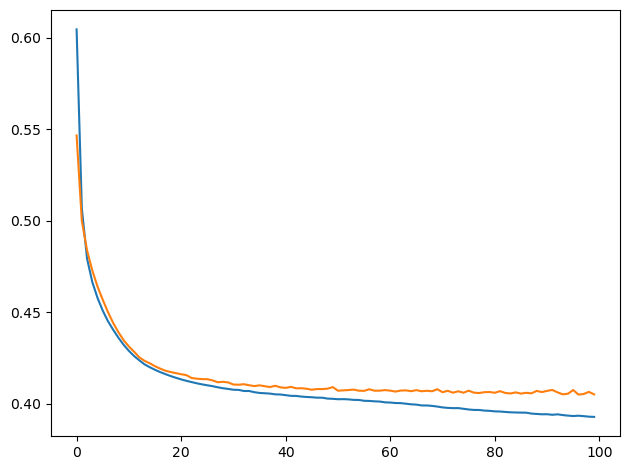

In [302]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.tight_layout()
plt.show()

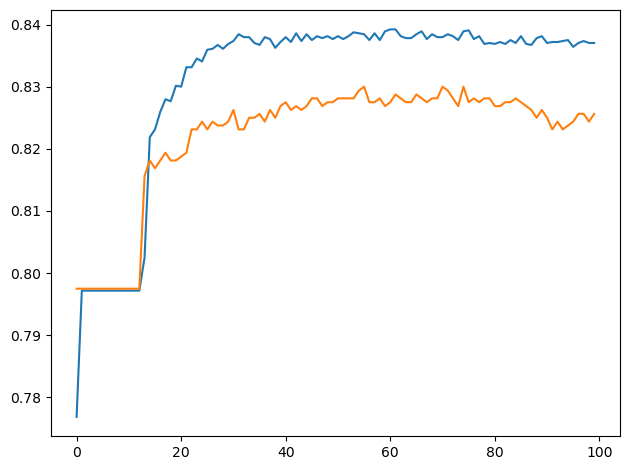

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.tight_layout()
plt.show()